In [9]:
import sys
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [6]:
clean_df = pd.read_csv("../Data/Processed_data/cleaned_nifty500.csv")

clean_df["Date"] = pd.to_datetime(clean_df["Date"])

clean_df.head()

,Date,Ticker,Open,High,Low,Close,Volume
0,2021-06-09,360ONE,260.813755,262.150806,249.887157,251.816010,59152.0
1,2021-06-10,360ONE,253.997012,260.046642,251.848943,257.131409,41084.0
2,2021-06-11,360ONE,259.443804,263.246739,256.714877,260.758942,232800.0
3,2021-06-14,360ONE,261.931602,263.027550,258.939658,259.619141,74364.0
4,2021-06-15,360ONE,260.791773,260.791773,252.144728,253.821533,149636.0


Dataset Summary

In [7]:
print("Rows :", clean_df.shape[0])
print("Columns :", clean_df.shape[1])
print("Companies :", clean_df["Ticker"].nunique())
print("Start :", clean_df["Date"].min())
print("End :", clean_df["Date"].max())

Rows : 551643
Columns : 7
Companies : 500
Start : 2021-06-09 00:00:00
End : 2026-06-09 00:00:00


Top Companies by Records

In [8]:
company_count = clean_df["Ticker"].value_counts()

company_count.head(10)

Ticker
GRSE          1235
ITC           1235
YESBANK       1234
UCOBANK       1234
AARTIIND      1234
ZYDUSWELL     1234
MPHASIS       1234
ADANIGREEN    1234
ADANIPORTS    1234
ADANIPOWER    1234
Name: count, dtype: int64

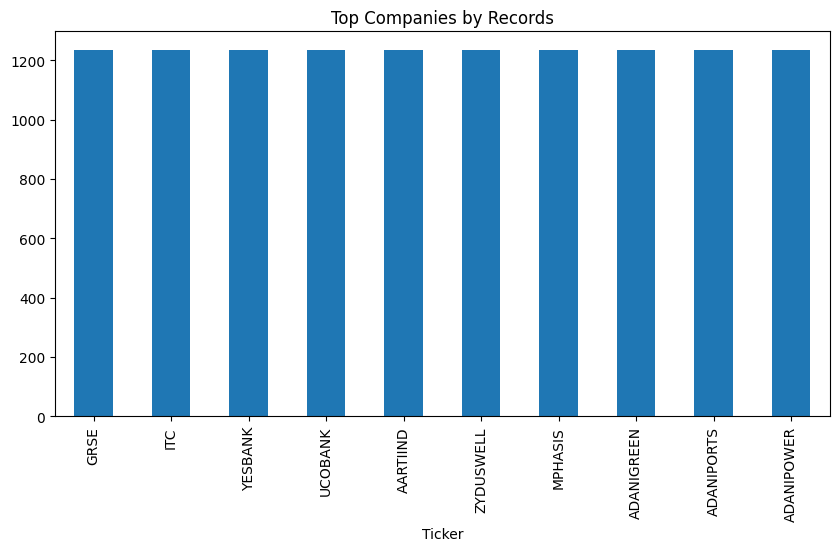

In [10]:
company_count.head(10).plot(kind="bar", figsize=(10,5))

plt.title("Top Companies by Records")

plt.show()

Highest Closing Price

In [11]:
highest_close = (
    clean_df.groupby("Ticker")["Close"]
    .max()
    .sort_values(ascending=False)
)

highest_close.head(10)

Ticker
MRF           162288.578125
HONAUT         58357.328125
PAGEIND        51217.289062
BOSCHLTD       41495.000000
3MINDIA        39344.750000
POWERINDIA     38445.000000
ABBOTINDIA     35195.000000
SHREECEM       32253.597656
FORCEMOT       25776.000000
PTCIL          19380.000000
Name: Close, dtype: float64

Highest Trading Volume

In [12]:
highest_volume = (
    clean_df.groupby("Ticker")["Volume"]
    .sum()
    .sort_values(ascending=False)
)

highest_volume.head(10)

Ticker
IDEA          4.134890e+11
YESBANK       1.763404e+11
SUZLON        1.069849e+11
JPPOWER       9.286912e+10
ETERNAL       7.215590e+10
IRB           6.405968e+10
ADANIPOWER    6.383874e+10
TATASTEEL     6.383625e+10
RPOWER        6.006042e+10
PNB           5.812445e+10
Name: Volume, dtype: float64

Daily Return

In [13]:
clean_df["Daily_Return"] = (
    clean_df.groupby("Ticker")["Close"]
    .pct_change()
)

In [14]:
clean_df.head()

,Date,Ticker,Open,High,Low,Close,Volume,Daily_Return
0,2021-06-09,360ONE,260.813755,262.150806,249.887157,251.816010,59152.0,NaN
1,2021-06-10,360ONE,253.997012,260.046642,251.848943,257.131409,41084.0,0.021108
2,2021-06-11,360ONE,259.443804,263.246739,256.714877,260.758942,232800.0,0.014108
3,2021-06-14,360ONE,261.931602,263.027550,258.939658,259.619141,74364.0,-0.004371
4,2021-06-15,360ONE,260.791773,260.791773,252.144728,253.821533,149636.0,-0.022331


Best Performing Stocks

In [15]:
performance = (
    clean_df.groupby("Ticker")["Daily_Return"]
    .mean()
    .sort_values(ascending=False)
)

performance.head(10)

Ticker
CPPLUS        0.006123
ATHERENERG    0.004995
EMMVEE        0.003816
BELRISE       0.003800
BSE           0.003531
GROWW         0.003493
GVT&D         0.003312
TARIL         0.003276
APARINDS      0.003147
PIRAMALFIN    0.003135
Name: Daily_Return, dtype: float64

Most Volatile Stocks

In [16]:
volatility = (
    clean_df.groupby("Ticker")["Daily_Return"]
    .std()
    .sort_values(ascending=False)
)

volatility.head(10)

Ticker
OLAELEC    0.041931
MEESHO     0.041577
TARIL      0.038484
IDEA       0.037374
EMMVEE     0.036881
GPIL       0.036806
IFCI       0.036799
GROWW      0.036191
FACT       0.035866
GRSE       0.035505
Name: Daily_Return, dtype: float64

Closing Price Trend

In [17]:
stock = "RELIANCE"

df_stock = clean_df[
    clean_df["Ticker"] == stock
]

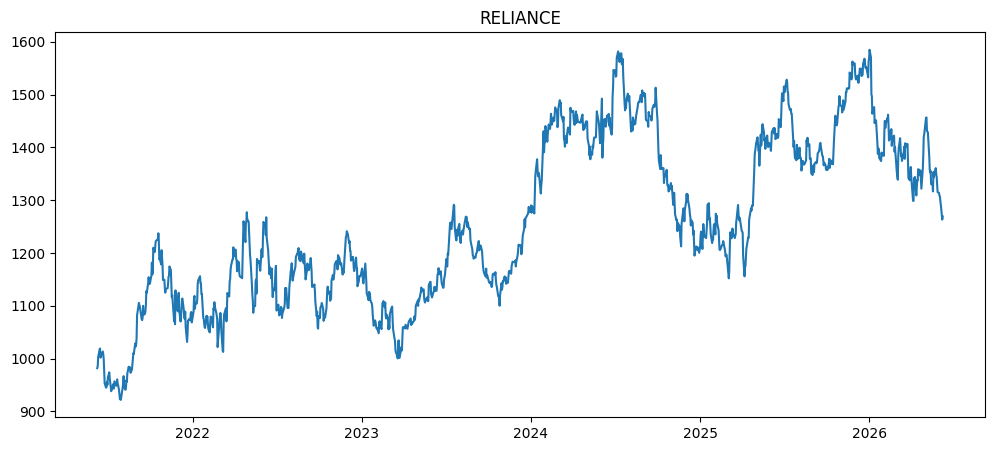

In [18]:
plt.figure(figsize=(12,5))

plt.plot(df_stock["Date"], df_stock["Close"])

plt.title(stock)

plt.show()

20-Day Moving Average (SMA20)

In [19]:
clean_df["SMA20"] = (
    clean_df.groupby("Ticker")["Close"]
    .transform(lambda x: x.rolling(20).mean())
)

50-Day Moving Average (SMA50)

In [21]:
clean_df["SMA50"] = (
    clean_df.groupby("Ticker")["Close"]
    .transform(lambda x: x.rolling(50).mean())
)

20-Day Exponential Moving Average (EMA20)

In [23]:
clean_df["EMA20"] = (
    clean_df.groupby("Ticker")["Close"]
    .transform(lambda x: x.ewm(span=20, adjust=False).mean())
)

Previous Day Closing Price (Lag 1)

In [24]:
clean_df["Lag1"] = (
    clean_df.groupby("Ticker")["Close"]
    .shift(1)
)

5-Day Lag

In [25]:
clean_df["Lag5"] = (
    clean_df.groupby("Ticker")["Close"]
    .shift(5)
)

20-Day Volatility

In [26]:
clean_df["Volatility20"] = (
    clean_df.groupby("Ticker")["Daily_Return"]
    .transform(lambda x: x.rolling(20).std())
)

Prediction Target

In [35]:
clean_df["Target"] = (
    clean_df.groupby("Ticker")["Close"]
    .shift(-1)
)

clean_df[["Ticker", "Date", "Close", "Target"]].head(10)

,Ticker,Date,Close,Target
0,360ONE,2021-06-09,251.816010,257.131409
1,360ONE,2021-06-10,257.131409,260.758942
2,360ONE,2021-06-11,260.758942,259.619141
3,360ONE,2021-06-14,259.619141,253.821533
4,360ONE,2021-06-15,253.821533,249.843323
5,360ONE,2021-06-16,249.843323,248.100723
6,360ONE,2021-06-17,248.100723,246.884247
7,360ONE,2021-06-18,246.884247,246.336227
8,360ONE,2021-06-21,246.336227,253.339340
9,360ONE,2021-06-22,253.339340,249.941940


Save the Feature Dataset

In [36]:
clean_df.to_csv(
    "../Data/Processed_data/features_nifty500.csv",
    index=False
)

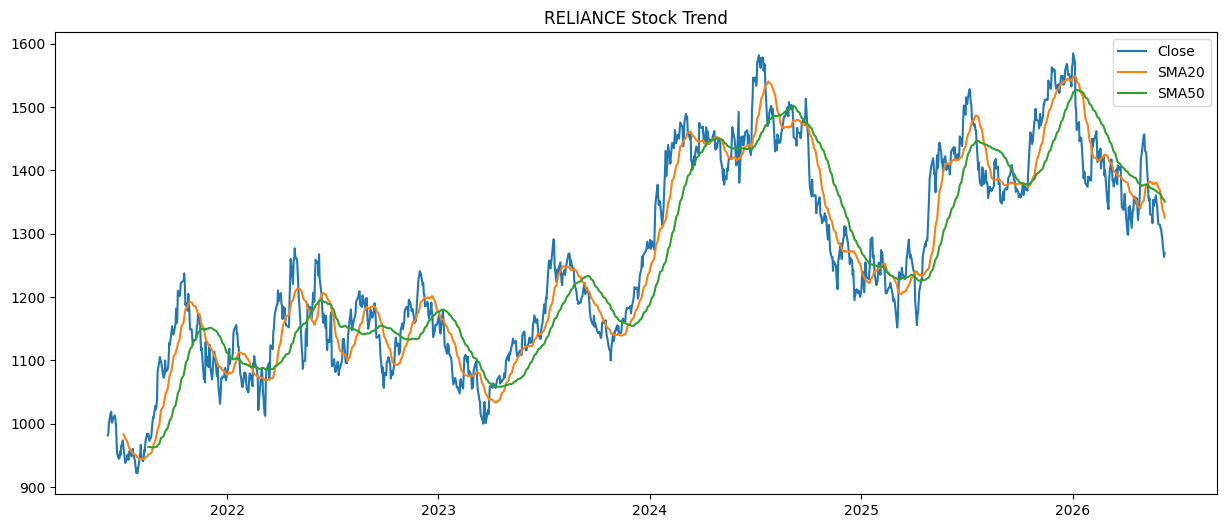

In [37]:
stock = "RELIANCE"

df_stock = clean_df[clean_df["Ticker"] == stock]

plt.figure(figsize=(15,6))

plt.plot(df_stock["Date"], df_stock["Close"], label="Close")
plt.plot(df_stock["Date"], df_stock["SMA20"], label="SMA20")
plt.plot(df_stock["Date"], df_stock["SMA50"], label="SMA50")

plt.legend()

plt.title("RELIANCE Stock Trend")

plt.show()